In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.nn.utils.rnn import pad_sequence
from transformers import BertConfig, BertModel
from sklearn.preprocessing import MaxAbsScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
from sklearn.feature_extraction import DictVectorizer
from sklearn.model_selection import train_test_split
import os
import json
import numpy as np
import pandas as pd
import random
import math
import matplotlib.pyplot as plt
from collections import Counter
from collections import defaultdict
from tqdm import tqdm

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

In [2]:
def load_data(path):
    data = []
    with open(path) as f:
        for line in f:
            data.append(json.loads(line))
    return data

## Domain1 Classifier

In [3]:
def prepare_ngram_features(data, vec=None, scaler=None, ngram_range=(1, 3), flag='train'):
    def extract_ngrams(doc, n):
        return [tuple(doc[i:i+n]) for i in range(len(doc)-n+1)]

    def get_ngram_dict(doc, ngram_range):
        ngram_freq = {}
        for n in range(ngram_range[0], ngram_range[1]+1):
            for g in extract_ngrams(doc, n):
                ngram_freq[g] = ngram_freq.get(g, 0) + 1
        return ngram_freq

    freq_dicts = [get_ngram_dict(item['text'], ngram_range) for item in data]

    if flag == 'train':
        vec = DictVectorizer(sparse=False)
        X = vec.fit_transform(freq_dicts)

        scaler = MaxAbsScaler()
        X_scaled = scaler.fit_transform(X)
    else:
        assert vec is not None and scaler is not None
        X = vec.transform(freq_dicts)
        X_scaled = scaler.transform(X)

    labels = [item['label'] for item in data]
    ids = [item['id'] for item in data]
    return X_scaled, labels, ids, vec, scaler


In [4]:
def prepare_ngram_batch(x_batch, vec, scaler, ngram_range=(1, 3)):
    """
    x_batch: Tensor of shape [batch_size, seq_len] (padded with 0s)
    Returns: Tensor of shape [batch_size, input_dim]
    """
    from collections import Counter

    def extract_ngrams(doc, n):
        return [tuple(doc[i:i+n]) for i in range(len(doc)-n+1)]

    def get_ngram_dict(doc):
        ngram_freq = {}
        for n in range(ngram_range[0], ngram_range[1]+1):
            for g in extract_ngrams(doc, n):
                if all(i != 0 for i in g):  # skip padded n-grams
                    ngram_freq[g] = ngram_freq.get(g, 0) + 1
        return ngram_freq

    x_list = x_batch.cpu().tolist()  # Convert to list of lists
    freq_dicts = [get_ngram_dict(seq) for seq in x_list]
    X = vec.transform(freq_dicts)
    X_scaled = scaler.transform(X)
    return torch.tensor(X_scaled, dtype=torch.float32)


In [5]:
def plot_confusion_matrix(labels, preds, class_names):
    """Plot and return confusion matrix figure"""
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)
    
    # Add labels
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=class_names, 
           yticklabels=class_names,
           title='Confusion Matrix',
           ylabel='True label',
           xlabel='Predicted label')

    # Rotate tick labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    # Add text annotations
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    
    fig.tight_layout()

In [6]:
domain1_path = 'data/domain1_train_data.json'
domain1_data = load_data(domain1_path)

In [7]:
domain1_train_data, domain1_val_data = train_test_split(domain1_data, test_size=0.2, random_state=42)

In [8]:
X_train, y_train, train_ids, vec, scaler = prepare_ngram_features(domain1_train_data, flag='train')
X_val, y_val, val_ids, _, _ = prepare_ngram_features(domain1_val_data, vec=vec, scaler=scaler, flag='val')

In [9]:
train_dataset = TensorDataset(torch.tensor(X_train).float(),
                              torch.tensor(y_train))

val_dataset = TensorDataset(torch.tensor(X_val).float(),
                            torch.tensor(y_val))


In [10]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [11]:

class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x


# Instantiate model, loss function, and optimizer
domain1_model = SimpleMLP(input_dim=X_train.shape[1], hidden_dim=64, output_dim=len(set(y_train)))
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(domain1_model.parameters(), lr=1e-3, weight_decay=0.01)

# Train
epochs = 10
best_val_loss = float('inf')
patience = 1
trigger_times = 0

def evaluate(model, data_loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            total_loss += loss.item() * batch_x.size(0)  # accumulate weighted by batch size

            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(batch_y.cpu().numpy())

    avg_loss = total_loss / len(all_labels)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    return avg_loss, acc, f1, all_preds, all_labels

for epoch in range(1, epochs + 1):
    print(f"\nEpoch {epoch}/{epochs}")

    domain1_model.train()
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        logits = domain1_model(batch_x)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()

    # Evaluate
    train_loss, train_acc, train_f1, _, _ = evaluate(domain1_model, train_loader, criterion)
    val_loss, val_acc, val_f1, val_preds, val_labels = evaluate(domain1_model, val_loader, criterion)

    print(f"Train loss: {train_loss:.4f}, accuracy: {train_acc:.4f}, f1: {train_f1:.4f}")
    print(f"Val   loss: {val_loss:.4f}, accuracy: {val_acc:.4f}, f1: {val_f1:.4f}")
    #plot_confusion_matrix(val_labels, val_preds, ['HUMAN', 'MACHINE'])
    #print("\nClassification Report (Val):")
    #print(classification_report(val_labels, val_preds, target_names=['HUMAN', 'MACHINE']))

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        trigger_times = 0
    else:
        trigger_times += 1
        print(f"Validation loss did not improve. Trigger times: {trigger_times}")
        if trigger_times >= patience:
            print("Early stopping triggered.")
            break


Epoch 1/10
Train loss: 0.1698, accuracy: 0.9962, f1: 0.9962
Val   loss: 0.3573, accuracy: 0.9650, f1: 0.9671

Epoch 2/10
Train loss: 0.0348, accuracy: 0.9975, f1: 0.9975
Val   loss: 0.2239, accuracy: 0.9750, f1: 0.9761

Epoch 3/10
Train loss: 0.0411, accuracy: 0.9975, f1: 0.9975
Val   loss: 0.2136, accuracy: 0.9750, f1: 0.9763

Epoch 4/10
Train loss: 0.0286, accuracy: 0.9975, f1: 0.9975
Val   loss: 0.1788, accuracy: 0.9800, f1: 0.9810

Epoch 5/10
Train loss: 0.0263, accuracy: 0.9975, f1: 0.9975
Val   loss: 0.1635, accuracy: 0.9800, f1: 0.9811

Epoch 6/10
Train loss: 0.0207, accuracy: 0.9975, f1: 0.9975
Val   loss: 0.1528, accuracy: 0.9750, f1: 0.9763

Epoch 7/10
Train loss: 0.0206, accuracy: 0.9975, f1: 0.9975
Val   loss: 0.1493, accuracy: 0.9750, f1: 0.9763

Epoch 8/10
Train loss: 0.0169, accuracy: 0.9975, f1: 0.9975
Val   loss: 0.1377, accuracy: 0.9750, f1: 0.9763

Epoch 9/10
Train loss: 0.0161, accuracy: 0.9975, f1: 0.9975
Val   loss: 0.1314, accuracy: 0.9750, f1: 0.9763

Epoch 10/

## Domain2 Classifier

In [12]:
class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = [torch.tensor(t, dtype=torch.long) for t in texts]
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

def collate_fn(batch):
    texts, labels = zip(*batch)
    padded = torch.nn.utils.rnn.pad_sequence(texts, batch_first=True)
    return padded, torch.tensor(labels)

In [13]:
class LSTMClassifier(torch.nn.Module):
    def __init__(self, vocab_size=17120, embedding_dim=128, hidden_dim=64):
        super().__init__()
        self.embedding = torch.nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = torch.nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = torch.nn.Linear(hidden_dim, 2)

    def forward(self, x):
        x = self.embedding(x)
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1])

In [14]:
class SimpleMLP(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super(SimpleMLP, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):  # x: (batch_size, seq_len)
        embedded = self.embedding(x)  # (batch_size, seq_len, embed_dim)
        pooled = embedded.mean(dim=1)  # mean pooling over sequence length
        x = self.relu(self.fc1(pooled))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [15]:
domain2_path = 'data/domain2_train_data.json'
domain2_data = load_data(domain2_path)

In [16]:
domain2_train_data, domain2_val_data = train_test_split(domain2_data, test_size=0.2, random_state=42)

In [17]:
label_counts = Counter(d["label"] for d in domain2_train_data)
print(label_counts)

Counter({1: 3812, 0: 188})


In [18]:
max_count = max(label_counts.values())

In [19]:
label_to_data = defaultdict(list)
for d in domain2_train_data:
    label_to_data[d["label"]].append(d)

In [20]:
oversampled_domain2_train_data = []

for label, items in label_to_data.items():
    n_to_sample = max_count - len(items)
    if n_to_sample > 0:
        sampled = random.choices(items, k=n_to_sample)
        oversampled_domain2_train_data.extend(items + sampled)
    else:
        oversampled_domain2_train_data.extend(items)

In [21]:
random.shuffle(oversampled_domain2_train_data)

In [22]:
#domain2_X_train = [d['text'] for d in oversampled_domain2_train_data]
#domain2_y_train = [d['label'] for d in oversampled_domain2_train_data]
domain2_X_train = [d['text'] for d in domain2_train_data]
domain2_y_train = [d['label'] for d in domain2_train_data]

domain2_X_val = [d['text'] for d in domain2_val_data]
domain2_y_val = [d['label'] for d in domain2_val_data]
train_ds = TextDataset(domain2_X_train , domain2_y_train)
val_ds = TextDataset(domain2_X_val, domain2_y_val)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=64, collate_fn=collate_fn)

In [23]:
#domain2_model = LSTMClassifier().to(device)
#optimizer = torch.optim.Adam(domain2_model.parameters(), lr=1e-4)
#criterion = torch.nn.CrossEntropyLoss()
domain2_model = SimpleMLP(vocab_size=17120, embed_dim=128, hidden_dim=64, output_dim=2).to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(domain2_model.parameters(), lr=1e-3, weight_decay=0.01)

from sklearn.metrics import accuracy_score, recall_score

for epoch in range(7):
    # ======== Training ========
    domain2_model.train()
    all_preds_train, all_labels_train = [], []
    running_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = domain2_model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        running_loss += loss.item()
        pred_labels = preds.argmax(dim=1)
        all_preds_train.extend(pred_labels.cpu().numpy())
        all_labels_train.extend(yb.cpu().numpy())

    train_loss = running_loss / len(train_loader)
    train_acc = accuracy_score(all_labels_train, all_preds_train)
    train_recall = recall_score(all_labels_train, all_preds_train, average=None)

    # ======== Validation ========
    domain2_model.eval()
    all_preds_val, all_labels_val = [], []
    val_loss_total = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = domain2_model(xb)
            loss = criterion(preds, yb)
            val_loss_total += loss.item()

            pred_labels = preds.argmax(dim=1)
            all_preds_val.extend(pred_labels.cpu().numpy())
            all_labels_val.extend(yb.cpu().numpy())

    val_loss = val_loss_total / len(val_loader)
    val_acc = accuracy_score(all_labels_val, all_preds_val)
    val_recall = recall_score(all_labels_val, all_preds_val, average=None)

    # ======== Output ========
    print(f"Epoch {epoch + 1}")
    print(f"  Train Loss: {train_loss:.4f} | Acc: {train_acc:.3f} | Recall: {train_recall[0]}")
    print(f"  Val   Loss: {val_loss:.4f} | Acc: {val_acc:.3f}   | Recall: {val_recall[0]}")

Epoch 1
  Train Loss: 0.3779 | Acc: 0.897 | Recall: 0.0425531914893617
  Val   Loss: 0.2120 | Acc: 0.938   | Recall: 0.0
Epoch 2
  Train Loss: 0.1661 | Acc: 0.953 | Recall: 0.0
  Val   Loss: 0.1937 | Acc: 0.938   | Recall: 0.0
Epoch 3
  Train Loss: 0.1522 | Acc: 0.953 | Recall: 0.0
  Val   Loss: 0.1819 | Acc: 0.938   | Recall: 0.0
Epoch 4
  Train Loss: 0.1402 | Acc: 0.953 | Recall: 0.0
  Val   Loss: 0.1695 | Acc: 0.938   | Recall: 0.0
Epoch 5
  Train Loss: 0.1304 | Acc: 0.953 | Recall: 0.0
  Val   Loss: 0.1597 | Acc: 0.938   | Recall: 0.0
Epoch 6
  Train Loss: 0.1222 | Acc: 0.953 | Recall: 0.0
  Val   Loss: 0.1501 | Acc: 0.938   | Recall: 0.0
Epoch 7
  Train Loss: 0.1137 | Acc: 0.953 | Recall: 0.005319148936170213
  Val   Loss: 0.1433 | Acc: 0.938   | Recall: 0.0


## Domain Head

In [24]:
class TextDataset(Dataset):
    def __init__(self, data, flag='train'):
        self.data = data
        self.flag = flag

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        ind = torch.tensor(row['id'], dtype=torch.int)
        text = torch.tensor(row['text'][:2048], dtype=torch.long)
        if self.flag != 'test':
            domain = torch.tensor(row['domain'], dtype=torch.long)
            return text, domain, ind
        else:
            return text, ind

class DataFactory(object):
    def __init__(self, domain1_path, domain2_path, test_path, max_len=512):
        self.domain1_path = domain1_path
        self.domain2_path = domain2_path
        self.test_path = test_path
        self.max_len = max_len
        domain1 = pd.read_json(self.domain1_path, lines=True)
        domain2 = pd.read_json(self.domain2_path, lines=True)
        domain1['domain']=0
        domain2['domain']=1
        self.test_data = pd.read_json(self.test_path, lines=True)
        self.merged_df = pd.concat([domain1[['text', 'domain', 'id']], domain2[['text', 'domain', 'id']]], ignore_index=True)

    def collate_fn(self, batch):
        texts, domains, ids = zip(*batch)
        padded_texts = pad_sequence(texts, batch_first=True, padding_value=0)
        mask = (padded_texts != 0).long() 
        domains = torch.stack(domains)
        ids = torch.stack(ids)
        return padded_texts, mask, domains, ids

    def collate_fn_test(self, batch):
        texts, ids = zip(*batch)
        padded_texts = pad_sequence(texts, batch_first=True, padding_value=0)
        mask = (padded_texts != 0).long() 
        ids = torch.stack(ids)
        return padded_texts, mask, ids
    
    def get_dataloader(self, batch_size=32):
        #train_data, val_data = train_test_split(self.merged_df, test_size=0.3, random_state=42)
        
        domain1_train_df = pd.DataFrame(domain1_train_data)
        domain2_train_df = pd.DataFrame(domain2_train_data)
        domain1_val_df = pd.DataFrame(domain1_val_data)
        domain2_val_df = pd.DataFrame(domain2_val_data)

        # Add domain labels
        domain1_train_df['domain'] = 0
        domain2_train_df['domain'] = 1
        domain1_val_df['domain'] = 0
        domain2_val_df['domain'] = 1
        
        train_data = pd.concat([domain1_train_df, domain2_train_df], ignore_index=True)
        val_data = pd.concat([domain1_val_df, domain2_val_df], ignore_index=True)

        train_dataset = TextDataset(train_data, flag='train')
        val_dataset = TextDataset(val_data, flag='val')
        test_dataset = TextDataset(self.test_data, flag='test')

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=self.collate_fn)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=self.collate_fn)
        test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=self.collate_fn_test)

        return train_loader, val_loader, test_loader

    def get_vocabsize(self):
        all_texts = self.merged_df['text'].tolist()
        all_tokens = [token for text in all_texts for token in text]
        vocab_size = len(Counter(all_tokens))
        return vocab_size+1

    def augment(tokens, drop_prob=0.1):
        return [tok for tok in tokens if tok != 0 and random.random() > drop_prob] or tokens

    def collate_contrastive(batch):
        # batch: [(tok, label_domain), ...]
        seqs, domains = [], []
        for tok, lab in batch:
            view1 = torch.tensor([CLS_ID]+tok, dtype=torch.long)
            view2 = torch.tensor([CLS_ID]+augment(tok), dtype=torch.long)
            seqs.extend([view1, view2])          # 2B
            domains.extend([lab, lab])
        pad = pad_sequence(seqs, batch_first=True, padding_value=PAD_ID)
        mask= (pad != PAD_ID).long()
        return pad, mask, torch.tensor(domains)   # labels 仍是域标签 0/1


        
        

In [25]:
class Classifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, hidden_dim, num_layers, num_classes=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.positional_encoding = nn.Parameter(torch.zeros(1, 2048, embed_dim))
        self.transformer = nn.Transformer(
            d_model=embed_dim, nhead=num_heads, num_encoder_layers=num_layers, dim_feedforward=hidden_dim
        )
        self.fc = nn.Linear(embed_dim, num_classes+2)
        self.proj = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(inplace=True),
            nn.Linear(embed_dim, hidden_dim)
        )

    def forward(self, x, x_mask):
        # x: (batch_size, seq_len)
        B, L = x.shape
        x = self.embedding(x) + self.positional_encoding[:, :L, :]
        x = x.permute(1, 0, 2)  # Transformer expects (seq_len, batch_size, embed_dim)
        x = self.transformer(x, x)  # Using the same input as both src and tgt
        x = x.mean(dim=0)  # Pooling over the sequence dimension
        logits = self.fc(x)
        z = self.proj(x)              # (B, proj_dim)
        z = F.normalize(z, dim=1)
        return logits, z


class BERTClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, hidden_dim, num_layers, num_classes=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.positional_encoding = nn.Parameter(torch.zeros(1, 2048, embed_dim))
        self.fc = nn.Linear(embed_dim, num_classes)
        self.proj = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(inplace=True),
            nn.Linear(embed_dim, hidden_dim)
        )
        config = BertConfig(
            vocab_size=vocab_size,
            hidden_size=embed_dim,
            num_hidden_layers=num_layers,
            num_attention_heads=num_heads,
            intermediate_size=hidden_dim,
            max_position_embeddings=2048,
        )
        self.bert = BertModel(config)

    def forward(self, x, x_mask):
        if x.size(1) == 0:
            # Return dummy logits and embeddings with appropriate batch size
            batch_size = x.size(0)
            dummy_logits = torch.zeros(batch_size, self.fc.out_features, device=x.device)
            dummy_z = torch.zeros(batch_size, self.proj[-1].out_features, device=x.device)
            return dummy_logits, dummy_z
        out = self.bert(input_ids=x,
                        attention_mask=x_mask)
        sequence_output = out.last_hidden_state
        cls_vec = sequence_output[:, 0, :]
        logits = self.fc(cls_vec)
        z = self.proj(cls_vec)              
        z = F.normalize(z, dim=1)
        return logits, z

# Initialize the model
class Main(object):
    def __init__(self, configs):
        random.seed(configs.seed)
        np.random.seed(configs.seed)
        torch.manual_seed(configs.seed)
        self.configs = configs
        self.name = configs.name
        self.embed_dim = configs.embed_dim
        self.num_heads = configs.num_heads
        self.hidden_dim = configs.hidden_dim
        self.num_layers = configs.num_layers
        self.num_classes = configs.num_classes
        self.criterion = nn.CrossEntropyLoss()
        self.datafactory = DataFactory(configs.path1, configs.path2, configs.test_path)
        self.train_loader, self.val_loader, self.test_loader = self.datafactory.get_dataloader(batch_size=configs.batch_size)
        self.vocab_size = self.datafactory.get_vocabsize()
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        # self.model = Classifier(self.vocab_size, self.embed_dim, self.num_heads, self.hidden_dim, self.num_layers, self.num_classes).to(self.device)
        self.model = BERTClassifier(self.vocab_size, self.embed_dim, self.num_heads, self.hidden_dim, self.num_layers, self.num_classes).to(self.device)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=1e-4)
        self.num_epochs = configs.num_epochs
        self.metric1 = accuracy_score
        self.metric2 = f1_score
        self.tau = configs.tau

    def __save__(self):
        path = os.path.join(f'./checkpoints/{self.name}')
        if not os.path.exists(path):
            os.makedirs(path)
        torch.save(self.model.state_dict(), f'{path}/{self.name}.pt')

    def __load__(self):
        path = os.path.join(f'./checkpoints/{self.name}')
        if not os.path.exists(path):
            os.makedirs(path)
        self.model.load_state_dict(torch.load(f'{path}/{self.name}.pt', map_location=self.device))

    # def supcon_loss(self, z: torch.Tensor, y: torch.Tensor, T: float = 0.07):
    #     sim = torch.matmul(z, z.T) / T             # (N, N)
    #     sim_max, _ = sim.max(dim=1, keepdim=True)
    #     sim = sim - sim_max.detach()
    #     N         = len(z)
    #     eye_bool  = torch.eye(N, dtype=torch.bool, device=z.device)
    #     mask      = ~eye_bool                  # True 表示非自己
    
    #     exp_sim   = torch.exp(sim) * mask      # 元素乘，float*bool 会自动转 float
    #     pos_mask  = y.unsqueeze(0) == y.unsqueeze(1)  # (N, N) 布尔型
    
    #     pos_sim   = exp_sim * pos_mask         # 只保留同标签对
    #     loss_i    = -torch.log(pos_sim.sum(1) / exp_sim.sum(1))
    #     return loss_i.mean

    def supcon_loss(self, z: torch.Tensor, y: torch.Tensor, T: float = 0.07) -> torch.Tensor:
        """
        Computes the Supervised Contrastive Loss (SupCon) for a batch.
        
        Args:
            z: Tensor of shape (N, D), L2-normalized projection vectors.
            y: LongTensor of shape (N,), integer class labels.
            T: Float, temperature parameter.
        
        Returns:
            A scalar Tensor containing the mean SupCon loss over the batch.
        """
        N = z.size(0)
        
        # 1) Pairwise cosine similarities scaled by temperature → (N, N)
        sim = torch.matmul(z, z.T) / T
        
        # 2) Numerical stability: subtract max per row
        sim_max, _ = sim.max(dim=1, keepdim=True)
        sim = sim - sim_max.detach()
        
        # 3) Exponentiate and zero out self-similarities on the diagonal
        exp_sim = torch.exp(sim)
        eye_mask = torch.eye(N, dtype=torch.bool, device=z.device)
        exp_sim = exp_sim.masked_fill(eye_mask, 0.0)
        
        # 4) Build mask for positives: same label across batch
        pos_mask = y.unsqueeze(0) == y.unsqueeze(1)  # shape (N, N)
        
        # 5) Sum of positive similarities and sum of all similarities
        pos_sum = (exp_sim * pos_mask.float()).sum(dim=1)
        all_sum = exp_sim.sum(dim=1)
        
        # 6) Avoid log(0) by clamping to a small epsilon
        eps = 1e-6
        pos_sum = pos_sum.clamp_min(eps)
        all_sum = all_sum.clamp_min(eps)
        
        # 7) Compute per-sample loss and then average
        loss_i = -torch.log(pos_sum / all_sum)
        return loss_i.mean()


    
    def train(self):
        train_loader = self.train_loader
        min_loss = math.inf
        patience = 5
        for epoch in range(self.num_epochs):
            self.model.train()
            epoch_loss = []
            epoch_acc = []
            epoch_f1 = []
            for x, x_mask, y, ind in tqdm(self.train_loader):
                x, x_mask, y, ind = x.to(self.device), x_mask.to(self.device), y.to(self.device), ind.to(self.device)

                self.optimizer.zero_grad()
                outputs, z = self.model(x, x_mask)
                pred = torch.argmax(outputs, dim=1)
                loss_ce = self.criterion(outputs, y)
                loss_supcon = self.supcon_loss(z, y)
                loss = loss_ce + loss_supcon
                loss.backward()
                self.optimizer.step()
                epoch_loss.append(loss.item())
                epoch_acc.append(self.metric1(pred.detach().cpu(), y.detach().cpu()))
                epoch_f1.append(self.metric2(pred.detach().cpu(), y.detach().cpu(), average='macro'))

            epoch_loss = np.mean(epoch_loss)
            epoch_acc = np.mean(epoch_acc)
            epoch_f1 = np.mean(epoch_f1)
            print(f"Epoch {epoch + 1:>3}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}, F1: {epoch_f1:.4f}")

            vali_loss = self.validation()
            self.model.train()
            if vali_loss < min_loss:
                min_loss = vali_loss
                self.__save__()
            else:
                patience -= 1

            if not patience:
                break

        self.__load__()


    def validation(self):
        val_loader = self.val_loader
        self.model.eval()
        with torch.no_grad():
            vali_loss = []
            vali_acc = []
            vali_f1 = []
            for x, x_mask, y, ind in tqdm(val_loader):
                x, x_mask, y, ind = x.to(self.device), x_mask.to(self.device), y.to(self.device), ind.to(self.device)
                outputs, z = self.model(x, x_mask)
                pred = torch.argmax(outputs, dim=1)
                loss = self.criterion(outputs, y)
                vali_loss.append(loss.item())
                vali_acc.append(self.metric1(pred.detach().cpu(), y.detach().cpu()))
                vali_f1.append(self.metric2(pred.detach().cpu(), y.detach().cpu(), average='macro'))
                
            vali_loss = np.mean(vali_loss)
            vali_acc = np.mean(vali_acc)
            vali_f1 = np.mean(vali_f1)
            print(f"Validation Loss: {vali_loss:.4f}, Accuracy: {vali_acc:.4f}, F1: {vali_f1:.4f}")
            return vali_loss

    def test(self):
        test_loader = self.test_loader
        self.model.eval()
        self.__load__()
        all_ids, all_preds = [], []
        with torch.no_grad():
            for x, x_mask, ind in tqdm(test_loader):
                x, x_mask = x.to(self.device), x_mask.to(self.device)
                outputs, z = self.model(x, x_mask)
                pred = torch.argmax(outputs, dim=1).cpu()
                all_ids.append(ind)
                all_preds.append(pred)
        all_ids = torch.cat(all_ids).numpy()
        all_preds = torch.cat(all_preds).numpy()
        df = pd.DataFrame({
            "id":   all_ids,
            "domain": all_preds+1
        })
        df.to_csv(self.configs.save_path, index=False)
        print(f"Saved → {self.configs.save_path}")




In [26]:
class Config:
    name = 'BERT'
    embed_dim = 128
    num_heads = 16
    hidden_dim = 256
    num_layers = 2
    num_classes = 4
    path1 = 'data/domain1_train_data.json'
    path2 = 'data/domain2_train_data.json'
    test_path = 'data/test_data.json'
    num_epochs = 10
    batch_size = 16
    seed = 42
    tau=1.5
    save_path = "bert_domain.csv"

configs = Config()
main = Main(configs)

In [27]:
main.train()

100%|██████████| 300/300 [00:16<00:00, 17.98it/s]


Epoch   1, Loss: 1.0816, Accuracy: 0.8169, F1: 0.4820


100%|██████████| 75/75 [00:00<00:00, 99.93it/s] 


Validation Loss: 0.4021, Accuracy: 0.8342, F1: 0.8319


100%|██████████| 300/300 [00:17<00:00, 17.27it/s]


...

Validation Loss: 0.1336, Accuracy: 0.9692, F1: 0.8777


100%|██████████| 300/300 [00:16<00:00, 17.87it/s]


Epoch   8, Loss: 0.0091, Accuracy: 0.9988, F1: 0.9980


100%|██████████| 75/75 [00:00<00:00, 102.29it/s]

Validation Loss: 0.1593, Accuracy: 0.9633, F1: 0.8757


## Evaluation

In [28]:
class TextDataset(Dataset):
    def __init__(self, data, flag='train'):
        self.data = data
        self.flag = flag

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        ind = torch.tensor(row['id'], dtype=torch.int)
        text = torch.tensor(row['text'][:2048], dtype=torch.long)
        label = torch.tensor(row['label'], dtype=torch.int)
        if self.flag != 'test':
            domain = torch.tensor(row['domain'], dtype=torch.long)
            return text, domain, label, ind
        else:
            return text, ind

In [29]:
def collate_fn(batch):
    texts, domains, labels, ids = zip(*batch)
    padded_texts = pad_sequence(texts, batch_first=True, padding_value=0)
    mask = (padded_texts != 0).long() 
    domains = torch.stack(domains)
    labels = torch.stack(labels)
    ids = torch.stack(ids)
    return padded_texts, mask, domains, labels, ids

In [30]:
def unified_evaluate(domain_head, domain_specific_classifiers, dataloader, device='cpu'):
    domain_head.eval()
    for entry in domain_specific_classifiers.values():
        entry["model"].eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            # Unpack batch
            x, x_mask, y_domain, y_label, _ = batch
            x = x.to(device)
            x_mask = x_mask.to(device)
            y_domain = y_domain.to(device)
            y_label = y_label.to(device)

            # Predict domain using domain classifier
            domain_logits, _ = domain_head(x, x_mask)
            predicted_domains = torch.argmax(domain_logits, dim=1)

            # Route each input to the corresponding domain-specific classifier
            domain_preds = torch.empty_like(y_domain)
            for domain in [0, 1]:
                indices = (predicted_domains == domain).nonzero(as_tuple=True)[0]
                if len(indices) > 0:
                    x_d = x[indices]
                    model = domain_specific_classifiers[domain]["model"].to(device)
                    preprocessor = domain_specific_classifiers[domain]["preprocessor"]
                    if preprocessor is not None:
                        x_d = preprocessor(x_d).to(device)
                        
                    logits_d = model(x_d)
                    pred_d = torch.argmax(logits_d, dim=1)
                    domain_preds[indices] = pred_d

            all_preds.append(domain_preds.cpu())
            all_labels.append(y_label.cpu())

    # Compute metrics
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')

    print(f"Val   accuracy: {acc:.4f}, f1: {f1:.4f}")
    plot_confusion_matrix(all_labels, all_preds, ['HUMAN', 'MACHINE'])
    print("\nClassification Report (Val):")
    print(classification_report(all_labels, all_preds, target_names=['HUMAN', 'MACHINE']))

In [31]:
domain1_val_df = pd.DataFrame(domain1_val_data)
domain2_val_df = pd.DataFrame(domain2_val_data)

# Add domain labels
domain1_val_df['domain'] = 0
domain2_val_df['domain'] = 1

In [32]:
val_data = pd.concat([domain1_val_df, domain2_val_df], ignore_index=True)

val_dataset = TextDataset(val_data, flag='val')

val_loader = DataLoader(val_dataset, batch_size=configs.batch_size, shuffle=False, collate_fn=collate_fn)

In [33]:
domain_specific_classifiers = {
    0: {"model": domain1_model, "preprocessor": lambda x: prepare_ngram_batch(x, vec, scaler)},
    1: {"model": domain2_model, "preprocessor": None}
}

Val   accuracy: 0.9350, f1: 0.8259

Classification Report (Val):
              precision    recall  f1-score   support

       HUMAN       0.93      0.54      0.69       158
     MACHINE       0.94      0.99      0.96      1042

    accuracy                           0.94      1200
   macro avg       0.93      0.77      0.83      1200
weighted avg       0.93      0.94      0.93      1200



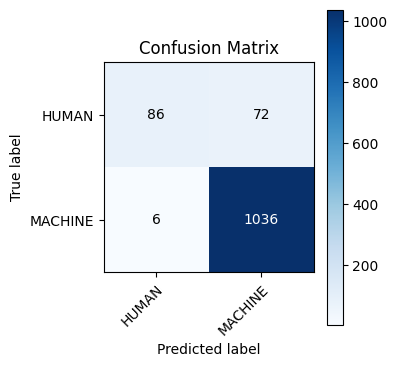

In [34]:
unified_evaluate(main.model, domain_specific_classifiers, val_loader , device='cpu')